# Unconditional Pokémon Diffusion Baseline

Trains a plain image diffusion model on a single art style — no type, stage, evolution chain, or art-style conditioning. Useful as a baseline to compare against the conditional model: how much does conditioning actually buy you?

What's removed vs the conditional notebook:
- No type / stage / art-style conditioning vector
- No previous-evolution image conditioning
- No CFG dropout or guidance scale (those only make sense with conditioning)
- The U-Net only takes `(x_t, t)` as input

What's kept:
- Cosine noise schedule
- Horizontal flip + small color jitter augmentation
- Foreground-weighted MSE loss (white background is still dominant)
- EMA, mixed precision, cosine LR, warm restart on LR=0


In [ ]:
# Cell 0: VRAM check
import torch
torch.cuda.empty_cache()
print(f"Free VRAM:  {(torch.cuda.mem_get_info()[0] / 1024**3):.1f} GB")
print(f"Total VRAM: {(torch.cuda.mem_get_info()[1] / 1024**3):.1f} GB")

In [1]:
# Cell 1: Imports & device
import os, json, math, random, shutil
from pathlib import Path
from collections import Counter
import numpy as np
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms

device = torch.device("cuda" if torch.cuda.is_available() else "mps")
print(f"Using device: {device}")
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print(f"GPU: {p.name}  |  VRAM: {p.total_memory / 1024**3:.1f} GB")

/Users/yugaank/Desktop/MSML-612-Project/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: mps


In [ ]:
# Optional: unzip data archive
# !unzip poke-data-temp.zip -d ./poke-data-temp

In [ ]:
# Optional: clear checkpoints
# !rm -rf checkpoints/

In [8]:
# Cell 2: Hyperparameters

# Paths
DATA_DIR = "./poke-data-temp"
JSON_FILES = ["sprite.json"]
OUTPUT_DIR = "./outputs"
CHECKPOINT_DIR = "./checkpoints"

# --- Image ---
IMG_SIZE = 128
IMG_CHANNELS = 3   # RGB

# --- Diffusion ---
TIMESTEPS = 1000
DDIM_STEPS = 100   # for fast sampling during training

# --- Training ---
BATCH_SIZE = 64
NUM_EPOCHS = 500
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 1e-4
EMA_DECAY = 0.999
GRAD_CLIP = 1.0
USE_AMP = True

# --- U-Net ---
BASE_CH = 64
CH_MULTS = (1, 2, 2, 4)
NUM_RES_BLOCKS = 2
ATTN_RESOLUTIONS = (16, 8)
DROPOUT = 0.1

# --- Loss ---
FG_WEIGHT_HIGH = 1.0
FG_WEIGHT_LOW  = 0.2

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

In [9]:
# Cell 3: File-existence sanity check

def check_files(data_dir, json_files):
    data_dir = Path(data_dir)
    print("Indexing files on disk...")
    all_files = {str(p) for p in data_dir.rglob("*") if p.is_file()}
    print(f"Found {len(all_files)} files on disk")

    missing, null_targets, total = [], [], 0
    for jf in json_files:
        json_path = data_dir / jf
        if not json_path.exists():
            print(f"✗ Missing JSON: {json_path}"); continue
        for i, entry in enumerate(json.load(open(json_path))):
            total += 1
            if entry.get("next_sprite") is None:
                null_targets.append(f"{jf}[{i}]")
            for field in ("next_sprite",):
                val = entry.get(field)
                if val is None: continue
                if str(data_dir / val) not in all_files:
                    missing.append(f"{jf}[{i}] {field}: {val}")

    if null_targets: print(f"{len(null_targets)} entries with null next_sprite")
    if missing:
        print(f"✗ {len(missing)}/{total} files missing. First few:")
        for m in missing[:10]: print(f"  - {m}")
    else:
        print(f"All files present ({total} entries checked)")

check_files(DATA_DIR, JSON_FILES)

Indexing files on disk...
Found 7738 files on disk
All files present (1994 entries checked)


In [ ]:
# Cell 4: Dataset (unconditional — only loads target image + foreground mask)

class PokemonUnconditionalDataset(Dataset):
    """
    Loads Pokemon images from a single JSON file. No conditioning is returned.
    Returns:
        target  — RGB image tensor in [-1, 1], shape (3, H, W)
        fg_mask — binary foreground mask from alpha, shape (1, H, W)
    """
    def __init__(self, data_dir, json_files, img_size=IMG_SIZE):
        self.data_dir = Path(data_dir)
        self.img_size = img_size
        self.samples = []

        for jf in json_files:
            path = self.data_dir / jf
            if not path.exists():
                print(f"Warning: {path} not found, skipping.")
                continue
            entries = json.load(open(path))
            entries = [e for e in entries if e.get("next_sprite") is not None]
            self.samples.extend(entries)
            print(f"Loaded {len(entries)} samples from {jf}")
        print(f"Total dataset size: {len(self.samples)}")

        # Mild color jitter on RGB only — alpha is handled separately
        self.rgb_jitter = transforms.ColorJitter(brightness=0.05, contrast=0.05, saturation=0.05)

        self.transform_rgb = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        ])

        self.transform_alpha = transforms.Compose([
            transforms.Resize((img_size, img_size), interpolation=transforms.InterpolationMode.NEAREST),
            transforms.ToTensor(),
        ])

    def _load_image(self, rel_path, flip=False):
        img = Image.open(self.data_dir / rel_path).convert("RGBA")
        if flip:
            img = img.transpose(Image.FLIP_LEFT_RIGHT)
        alpha = img.getchannel("A")

        # Composite onto white bg (matches the conditional notebook)
        white_bg = Image.new("RGB", img.size, (255, 255, 255))
        white_bg.paste(img.convert("RGB"), mask=alpha)

        rgb = self.rgb_jitter(white_bg)
        rgb_tensor = self.transform_rgb(rgb) * 2 - 1
        alpha_tensor = self.transform_alpha(alpha)
        return rgb_tensor, alpha_tensor

    def __getitem__(self, idx):
        # First half = original, second half = horizontally flipped
        flipped = idx >= len(self.samples)
        real_idx = idx % len(self.samples)
        s = self.samples[real_idx]

        rgb_target, alpha_target = self._load_image(s["next_sprite"], flip=flipped)
        fg_mask = (alpha_target > 0.0).float()

        return {"target": rgb_target, "fg_mask": fg_mask}

    def __len__(self):
        return len(self.samples) * 2   # doubled for hflip


In [11]:
# Cell 5: Noise schedule (cosine, Nichol & Dhariwal 2021)

class NoiseSchedule:
    def __init__(self, timesteps=TIMESTEPS, device="cpu", s=0.008):
        self.timesteps = timesteps
        self.device = device

        t = torch.linspace(0, 1, timesteps + 1, device=device)
        ab = torch.cos(((t + s) / (1 + s)) * math.pi / 2) ** 2
        ab = ab / ab[0]
        betas = (1 - ab[1:] / ab[:-1]).clamp(max=0.999)

        self.betas = betas
        self.alphas = 1.0 - betas
        self.alpha_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alpha_cumprod_prev = F.pad(self.alpha_cumprod[:-1], (1, 0), value=1.0)

        self.sqrt_alpha_cumprod = torch.sqrt(self.alpha_cumprod)
        self.sqrt_one_minus_alpha_cumprod = torch.sqrt(1.0 - self.alpha_cumprod)
        self.sqrt_recip_alpha = torch.sqrt(1.0 / self.alphas)
        self.posterior_variance = betas * (1.0 - self.alpha_cumprod_prev) / (1.0 - self.alpha_cumprod)

    def add_noise(self, x_0, t, noise=None):
        if noise is None: noise = torch.randn_like(x_0)
        sa  = self.sqrt_alpha_cumprod[t].view(-1, 1, 1, 1)
        s1m = self.sqrt_one_minus_alpha_cumprod[t].view(-1, 1, 1, 1)
        return sa * x_0 + s1m * noise, noise

    def _apply_step(self, x_t, t, pred_noise):
        betas_t  = self.betas[t].view(-1, 1, 1, 1)
        s1m      = self.sqrt_one_minus_alpha_cumprod[t].view(-1, 1, 1, 1)
        srecip   = self.sqrt_recip_alpha[t].view(-1, 1, 1, 1)
        mean = srecip * (x_t - betas_t / s1m * pred_noise)
        if t == 0: return mean
        var = self.posterior_variance[t].view(-1, 1, 1, 1)
        return mean + torch.sqrt(var) * torch.randn_like(x_t)

    @torch.no_grad()
    def ddpm_sample(self, model, shape, progress=True):
        x = torch.randn(shape, device=self.device)
        it = reversed(range(self.timesteps))
        if progress: it = tqdm(it, total=self.timesteps, desc="DDPM")
        for t in it:
            tt = torch.full((shape[0],), t, device=self.device, dtype=torch.long)
            eps = model(x, tt)
            x = self._apply_step(x, t, eps)
        return x.clamp(-1, 1)

    @torch.no_grad()
    def ddim_sample(self, model, shape, num_steps=DDIM_STEPS, eta=0.0, progress=True):
        step_indices = torch.linspace(self.timesteps - 1, 0, num_steps + 1, device=self.device).long()
        x = torch.randn(shape, device=self.device)
        rng = range(num_steps)
        if progress: rng = tqdm(rng, desc="DDIM")
        for i in rng:
            t  = step_indices[i].item()
            tp = step_indices[i + 1].item()
            tt = torch.full((shape[0],), t, device=self.device, dtype=torch.long)
            eps = model(x, tt)

            a_t  = self.alpha_cumprod[t]
            a_tp = self.alpha_cumprod[tp] if tp >= 0 else torch.tensor(1.0, device=self.device)
            x0p  = (x - torch.sqrt(1 - a_t) * eps) / torch.sqrt(a_t)
            x0p  = x0p.clamp(-1, 1)
            sigma = eta * torch.sqrt((1 - a_tp) / (1 - a_t) * (1 - a_t / a_tp))
            dir_xt = torch.sqrt((1 - a_tp - sigma ** 2).clamp(min=0)) * eps
            x = torch.sqrt(a_tp) * x0p + dir_xt
            if eta > 0 and tp > 0:
                x = x + sigma * torch.randn_like(x)
        return x.clamp(-1, 1)

In [12]:
# Cell 6: U-Net building blocks

class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim): super().__init__(); self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / (half - 1))
        args = t.float().unsqueeze(1) * freqs.unsqueeze(0)
        return torch.cat([torch.sin(args), torch.cos(args)], dim=1)


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, emb_dim, dropout=DROPOUT):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.emb_proj = nn.Linear(emb_dim, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.emb_proj(F.silu(emb)).unsqueeze(-1).unsqueeze(-1)
        h = self.conv2(self.dropout(F.silu(self.norm2(h))))
        return h + self.skip(x)


class SelfAttention(nn.Module):
    def __init__(self, channels, num_heads=4):
        super().__init__()
        self.norm = nn.GroupNorm(8, channels)
        self.num_heads = num_heads
        self.qkv  = nn.Conv2d(channels, channels * 3, 1)
        self.proj = nn.Conv2d(channels, channels, 1)

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x)
        qkv = self.qkv(h).reshape(B, 3, self.num_heads, C // self.num_heads, H * W)
        q, k, v = qkv.unbind(dim=1)
        q = q.transpose(-2, -1); k = k.transpose(-2, -1); v = v.transpose(-2, -1)
        h = F.scaled_dot_product_attention(q, k, v)
        h = h.transpose(-2, -1).reshape(B, C, H, W)
        return x + self.proj(h)


class Downsample(nn.Module):
    def __init__(self, ch): super().__init__(); self.op = nn.Conv2d(ch, ch, 3, stride=2, padding=1)
    def forward(self, x): return self.op(x)


class Upsample(nn.Module):
    def __init__(self, ch): super().__init__(); self.op = nn.Conv2d(ch, ch, 3, padding=1)
    def forward(self, x):
        return self.op(F.interpolate(x, scale_factor=2, mode="nearest"))

In [13]:
# Cell 7: Unconditional U-Net (only takes x and t)

class UnconditionalUNet(nn.Module):
    def __init__(self, img_channels=IMG_CHANNELS, time_embed_dim=128, base_ch=BASE_CH, ch_mults=CH_MULTS, num_res_blocks=NUM_RES_BLOCKS, attn_resolutions=ATTN_RESOLUTIONS, dropout=DROPOUT, img_size=IMG_SIZE):
        super().__init__()
        self.img_size = img_size
        self.attn_resolutions = set(attn_resolutions)

        emb_dim = time_embed_dim * 4

        # --- Time embedding (only conditioning input) ---
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_embed_dim),
            nn.Linear(time_embed_dim, emb_dim),
            nn.SiLU(),
            nn.Linear(emb_dim, emb_dim),
        )

        # --- Init conv ---
        self.init_conv = nn.Conv2d(img_channels, base_ch, 3, padding=1)

        # --- Down ---
        self.downs = nn.ModuleList()
        ch = base_ch
        skip_channels = [ch]
        cur_res = img_size

        for level, mult in enumerate(ch_mults):
            out_ch = base_ch * mult
            for _ in range(num_res_blocks):
                block = nn.ModuleDict({
                    "res":  ResBlock(ch, out_ch, emb_dim, dropout),
                    "attn": SelfAttention(out_ch) if cur_res in self.attn_resolutions else nn.Identity(),
                })
                self.downs.append(block)
                ch = out_ch
                skip_channels.append(ch)
            if level < len(ch_mults) - 1:
                self.downs.append(nn.ModuleDict({"down": Downsample(ch)}))
                skip_channels.append(ch)
                cur_res //= 2

        # --- Middle ---
        self.mid = nn.ModuleList([
            ResBlock(ch, ch, emb_dim, dropout),
            SelfAttention(ch),
            ResBlock(ch, ch, emb_dim, dropout),
        ])

        # --- Up ---
        self.ups = nn.ModuleList()
        cur_res = img_size // (2 ** (len(ch_mults) - 1))
        ch = base_ch * ch_mults[-1]

        for level, mult in reversed(list(enumerate(ch_mults))):
            out_ch = base_ch * mult
            for i in range(num_res_blocks + (1 if level > 0 else 0)):
                skip_ch = skip_channels.pop()
                block = nn.ModuleDict({
                    "res":  ResBlock(ch + skip_ch, out_ch, emb_dim, dropout),
                    "attn": SelfAttention(out_ch) if cur_res in self.attn_resolutions else nn.Identity(),
                })
                self.ups.append(block)
                ch = out_ch
            if level > 0:
                self.ups.append(nn.ModuleDict({"up": Upsample(ch)}))
                cur_res *= 2

        self.final_norm = nn.GroupNorm(8, ch)
        self.final_conv = nn.Conv2d(ch, img_channels, 3, padding=1)

    def forward(self, x, t):
        emb = self.time_mlp(t)

        h = self.init_conv(x)
        skips = [h]
        for block in self.downs:
            if "down" in block:
                h = block["down"](h); skips.append(h)
            else:
                h = block["res"](h, emb)
                if not isinstance(block["attn"], nn.Identity):
                    h = block["attn"](h)
                skips.append(h)

        h = self.mid[0](h, emb); h = self.mid[1](h); h = self.mid[2](h, emb)

        for block in self.ups:
            if "up" in block:
                h = block["up"](h)
            else:
                h = torch.cat([h, skips.pop()], dim=1)
                h = block["res"](h, emb)
                if not isinstance(block["attn"], nn.Identity):
                    h = block["attn"](h)

        return self.final_conv(F.silu(self.final_norm(h)))


# Sanity check
_m = UnconditionalUNet(
    img_channels=IMG_CHANNELS, base_ch=BASE_CH, ch_mults=CH_MULTS,
    num_res_blocks=NUM_RES_BLOCKS, attn_resolutions=ATTN_RESOLUTIONS,
    dropout=DROPOUT, img_size=IMG_SIZE,
).to(device)
with torch.no_grad():
    _x = torch.randn(2, IMG_CHANNELS, IMG_SIZE, IMG_SIZE, device=device)
    _t = torch.randint(0, TIMESTEPS, (2,), device=device)
    _y = _m(_x, _t)
    assert _y.shape == _x.shape
print(f"Unconditional U-Net OK. Params: {sum(p.numel() for p in _m.parameters()):,}")
del _m

Unconditional U-Net OK. Params: 19,167,235


In [14]:
# Cell 8: EMA

class EMA:
    def __init__(self, model, decay=EMA_DECAY):
        self.model = model; self.decay = decay
        self.shadow, self.backup = {}, {}
        for n, p in model.named_parameters():
            if p.requires_grad: self.shadow[n] = p.data.clone()

    @torch.no_grad()
    def update(self):
        for n, p in self.model.named_parameters():
            if p.requires_grad:
                self.shadow[n].mul_(self.decay).add_(p.data, alpha=1 - self.decay)

    def apply_shadow(self):
        for n, p in self.model.named_parameters():
            if p.requires_grad:
                self.backup[n] = p.data.clone()
                p.data.copy_(self.shadow[n])

    def restore(self):
        for n, p in self.model.named_parameters():
            if p.requires_grad:
                p.data.copy_(self.backup[n])
        self.backup = {}

    def to(self, device):
        for n in self.shadow:
            self.shadow[n] = self.shadow[n].to(device)

In [15]:
# Cell 9: Sampling helpers

@torch.no_grad()
def generate(model, noise_schedule, num_samples=8, use_ddim=True, ddim_steps=DDIM_STEPS, progress=True):
    model.eval()
    shape = (num_samples, IMG_CHANNELS, IMG_SIZE, IMG_SIZE)
    if use_ddim:
        x = noise_schedule.ddim_sample(model, shape, num_steps=ddim_steps, progress=progress)
    else:
        x = noise_schedule.ddpm_sample(model, shape, progress=progress)
    return (x + 1) / 2   # [0, 1]


def tensor_to_pil(tensor):
    img = tensor.cpu().permute(1, 2, 0).numpy()
    img = (img * 255).clip(0, 255).astype(np.uint8)
    return Image.fromarray(img).convert("RGB")


@torch.no_grad()
def save_sample_grid(model, ema, noise_schedule, epoch, n=8, cols=4):
    ema.apply_shadow()
    try:
        gen = generate(model, noise_schedule, num_samples=n, use_ddim=True, ddim_steps=DDIM_STEPS, progress=False)
        rows = (n + cols - 1) // cols
        grid = Image.new("RGB", (cols * IMG_SIZE, rows * IMG_SIZE), (255, 255, 255))
        for idx in range(n):
            r, c = divmod(idx, cols)
            grid.paste(tensor_to_pil(gen[idx]), (c * IMG_SIZE, r * IMG_SIZE))
        path = f"{OUTPUT_DIR}/samples_epoch_{epoch}.png"
        grid.save(path)
        print(f"  Saved samples to {path}")
    finally:
        ema.restore()

Loaded 1994 samples from sprite.json
Total dataset size: 1994
Total with flips: 3988


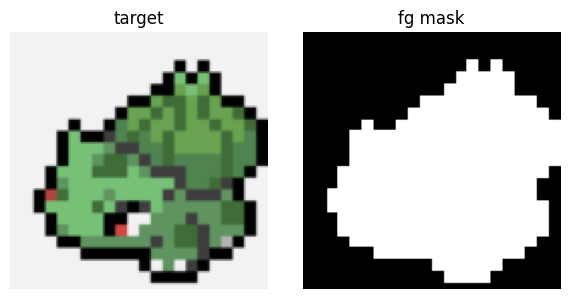

In [16]:
# Cell 10: Quick dataset sanity check
import matplotlib.pyplot as plt

_ds = PokemonUnconditionalDataset(DATA_DIR, JSON_FILES, IMG_SIZE)
print(f"Total with flips: {len(_ds)}")

s = _ds[0]
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
img = (s["target"] + 1) / 2
axes[0].imshow(img.permute(1, 2, 0)); axes[0].set_title("target"); axes[0].axis("off")
axes[1].imshow(s["fg_mask"][0], cmap="gray"); axes[1].set_title("fg mask"); axes[1].axis("off")
plt.tight_layout(); plt.show()
del _ds

In [19]:
# Cell 11: Training (unconditional baseline)

def train(resume_from=None):
    dataset = PokemonUnconditionalDataset(DATA_DIR, JSON_FILES, IMG_SIZE)

    dataloader = DataLoader(
        dataset, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=4, pin_memory=True, drop_last=True, persistent_workers=True,
    )

    model = UnconditionalUNet(
        img_channels=IMG_CHANNELS, base_ch=BASE_CH, ch_mults=CH_MULTS,
        num_res_blocks=NUM_RES_BLOCKS, attn_resolutions=ATTN_RESOLUTIONS,
        dropout=DROPOUT, img_size=IMG_SIZE,
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    noise_schedule = NoiseSchedule(TIMESTEPS, device=device)
    ema = EMA(model, decay=EMA_DECAY)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

    start_epoch, best_loss = 0, float("inf")
    recent_losses = []

    if resume_from is not None and os.path.exists(resume_from):
        ckpt = torch.load(resume_from, map_location=device)
        model.load_state_dict(ckpt["model_state_dict"])
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        if "ema_shadow" in ckpt:
            ema.shadow = ckpt["ema_shadow"]; ema.to(device)
        if "scaler_state" in ckpt: scaler.load_state_dict(ckpt["scaler_state"])
        if "loss_history" in ckpt: recent_losses = ckpt["loss_history"]
        start_epoch = ckpt["epoch"]
        best_loss = ckpt.get("loss", float("inf"))
        print(f"Resumed from epoch {start_epoch}, loss: {best_loss:.4f}")

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=max(1, NUM_EPOCHS - start_epoch)
    )

    print(f"Training on {len(dataset)} samples, {len(dataloader)} batches/epoch")
    print(f"Model params: {sum(p.numel() for p in model.parameters()):,}")

    for epoch in range(start_epoch, NUM_EPOCHS):
        model.train()
        ep_loss, n_batches = 0.0, 0

        pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
        for batch in pbar:
            target  = batch["target"].to(device, non_blocking=True)
            fg_mask = batch["fg_mask"].to(device, non_blocking=True)
            B = target.shape[0]

            t = torch.randint(0, TIMESTEPS, (B,), device=device)
            x_t, noise = noise_schedule.add_noise(target, t)

            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                pred_noise = model(x_t, t)

                # Foreground-weighted MSE — same trick as the conditional notebook
                weight_map = (FG_WEIGHT_LOW + (FG_WEIGHT_HIGH - FG_WEIGHT_LOW) * fg_mask)
                weight_map = weight_map.expand(-1, pred_noise.shape[1], -1, -1)
                sq_err = (pred_noise - noise) ** 2
                loss = (sq_err * weight_map).sum() / weight_map.sum()

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer); scaler.update()

            ema.update()
            ep_loss += loss.item(); n_batches += 1
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        avg_loss = ep_loss / max(1, n_batches)
        recent_losses.append(avg_loss)
        print(f"Epoch {epoch+1} | Avg Loss: {avg_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.6f}")
        scheduler.step()

        # Warm restart when LR hits zero
        if scheduler.get_last_lr()[0] <= 1e-7:
            print(f"  LR exhausted at epoch {epoch+1}, warm restarting at {LEARNING_RATE}")
            for g in optimizer.param_groups: g["lr"] = LEARNING_RATE
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=NUM_EPOCHS - epoch - 1
            )

        payload = {
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "ema_shadow": ema.shadow,
            "optimizer_state_dict": optimizer.state_dict(),
            "scaler_state": scaler.state_dict(),
            "loss": avg_loss,
            "loss_history": recent_losses,
        }
        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(payload, f"{CHECKPOINT_DIR}/ckpt_best.pt")
            print(f"  New best loss: {best_loss:.4f}")
        torch.save(payload, f"{CHECKPOINT_DIR}/ckpt_latest.pt")

        if (epoch + 1) % 50 == 0:
            save_sample_grid(model, ema, noise_schedule, epoch + 1)
            torch.save(payload, f"{CHECKPOINT_DIR}/ckpt_epoch_{epoch+1}.pt")

    return model, ema

# Kick off training:
model, ema = train()

# Or resume:
# model, ema = train(resume_from=f"{CHECKPOINT_DIR}/ckpt_latest.pt")

/var/folders/k3/gpnmxr9j64d9___5d1xq15nh0000gn/T/ipykernel_31544/852145569.py:20: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)


Loaded 1994 samples from sprite.json
Total dataset size: 1994
Training on 3988 samples, 62 batches/epoch
Model params: 19,167,235


PicklingError: Can't pickle local object <function PokemonUnconditionalDataset.__init__.<locals>.<lambda> at 0x1224ab5e0>

In [ ]:
# Cell 12: Inference

def load_for_inference(ckpt_path):
    model = UnconditionalUNet(
        img_channels=IMG_CHANNELS, base_ch=BASE_CH, ch_mults=CH_MULTS,
        num_res_blocks=NUM_RES_BLOCKS, attn_resolutions=ATTN_RESOLUTIONS,
        dropout=DROPOUT, img_size=IMG_SIZE,
    ).to(device)
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    ema = EMA(model, decay=EMA_DECAY)
    if "ema_shadow" in ckpt:
        ema.shadow = ckpt["ema_shadow"]; ema.to(device)
    print(f"Loaded ckpt from epoch {ckpt['epoch']}, loss {ckpt['loss']:.4f}")
    return model, ema, NoiseSchedule(TIMESTEPS, device=device)


def generate_baseline(model, ema, noise_schedule, n=16, cols=4,
                      ddim_steps=200, save_dir=None):
    """Generate n unconditional samples in a grid."""
    save_dir = save_dir or f"{OUTPUT_DIR}/generate_baseline"
    os.makedirs(save_dir, exist_ok=True)

    ema.apply_shadow()
    try:
        gen = generate(model, noise_schedule, num_samples=n,
                       use_ddim=True, ddim_steps=ddim_steps, progress=True)
        # save individual + grid
        rows = (n + cols - 1) // cols
        grid = Image.new("RGB", (cols * IMG_SIZE, rows * IMG_SIZE), (255, 255, 255))
        for i in range(n):
            pil = tensor_to_pil(gen[i])
            pil.save(f"{save_dir}/sample_{i:03d}_ddim{ddim_steps}.png")
            r, c = divmod(i, cols)
            grid.paste(pil, (c * IMG_SIZE, r * IMG_SIZE))
        grid.save(f"{save_dir}/grid_ddim{ddim_steps}.png")
        print(f"Saved {n} samples + grid to {save_dir}/")
        return [tensor_to_pil(gen[i]) for i in range(n)]
    finally:
        ema.restore()


# Example:
# model, ema, noise_schedule = load_for_inference(f"{CHECKPOINT_DIR}/ckpt_best.pt")
# generate_baseline(model, ema, noise_schedule, n=16, ddim_steps=100)
# generate_baseline(model, ema, noise_schedule, n=16, ddim_steps=200)

In [ ]:
# Cell 13: Loss plot
import matplotlib.pyplot as plt

ckpt = torch.load(f"{CHECKPOINT_DIR}/ckpt_latest.pt", map_location="cpu")
losses = ckpt["loss_history"]

plt.figure(figsize=(12, 4))
plt.plot(losses)
plt.xlabel("Epoch"); plt.ylabel("Avg Loss"); plt.title("Unconditional Baseline Loss")
plt.grid(True); plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/loss_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Total epochs: {len(losses)}")
print(f"Best loss: {min(losses):.4f} at epoch {losses.index(min(losses)) + 1}")

In [ ]:
# Cell 14: Zip outputs / checkpoints
import shutil, os
for name, src in [("checkpoints", CHECKPOINT_DIR), ("outputs", OUTPUT_DIR)]:
    zp = f"{name}.zip"
    if os.path.exists(zp): os.remove(zp)
    shutil.make_archive(name, "zip", src)
    print(f"Created {zp}")